In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.trainer import SobolevTrainer, GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put

from binomial_tree.binomial_tree import binomial_tree


In [2]:
S0 = 1.0
r = 0.1
sigma = 0.4
K = 2.0
T = 1.0
S_min = 1 / (3 * K)
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
# S0 = 25.0
# r = 0.1
# sigma = 0.4
# K = 25.0
# T = 1.0
# S_min = 1 / 3 * K
# S_max = 3 * K

# market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [4]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Mish()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

Iteration 0, Loss: 3.786740303039551
Iteration 100, Loss: 0.039945974946022034
Iteration 200, Loss: 0.026694022119045258
Iteration 300, Loss: 0.023518025875091553
Converged at epoch 394


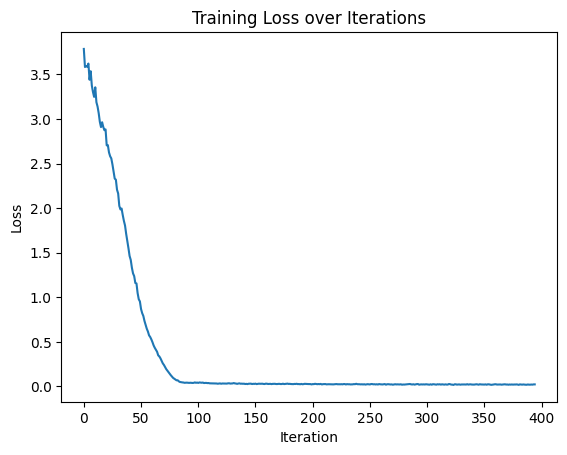

In [5]:
put_payoff = Put()
sobolev_trainer = SobolevTrainer(model_config, market_params, put_payoff, seed=42)
sobolev_trainer.train(batch_size=1000, epochs=10000, tol=1e-5)
sobolev_trainer.plot_losses()

Iteration 0, Loss: 5.371563911437988
Converged at epoch 99


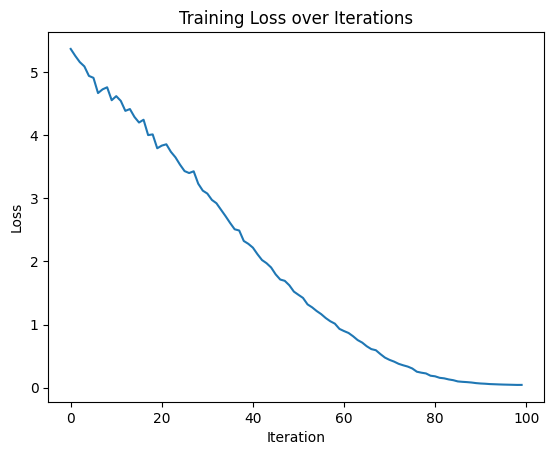

In [6]:
general_trainer = GeneralTrainer(model_config, market_params, put_payoff, seed=42)
general_trainer.train(num_samples=1000, iterations=10000, tol=1e-3)
general_trainer.plot_losses()

In [7]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(1e-6, T, num_T)  # avoid exactly zero maturity

sb_prices = np.zeros((num_T, num_S))
nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        sb_prices[i, j] = sobolev_trainer.predict(t_val, s_val).item()
        nn_prices[i, j] = general_trainer.predict(t_val, s_val).item()
        bt_price, _, _ = binomial_tree(S=s_val, K=K, T=t_val, r=r, sigma=sigma, n=200)
        bt_prices[i, j] = float(bt_price)

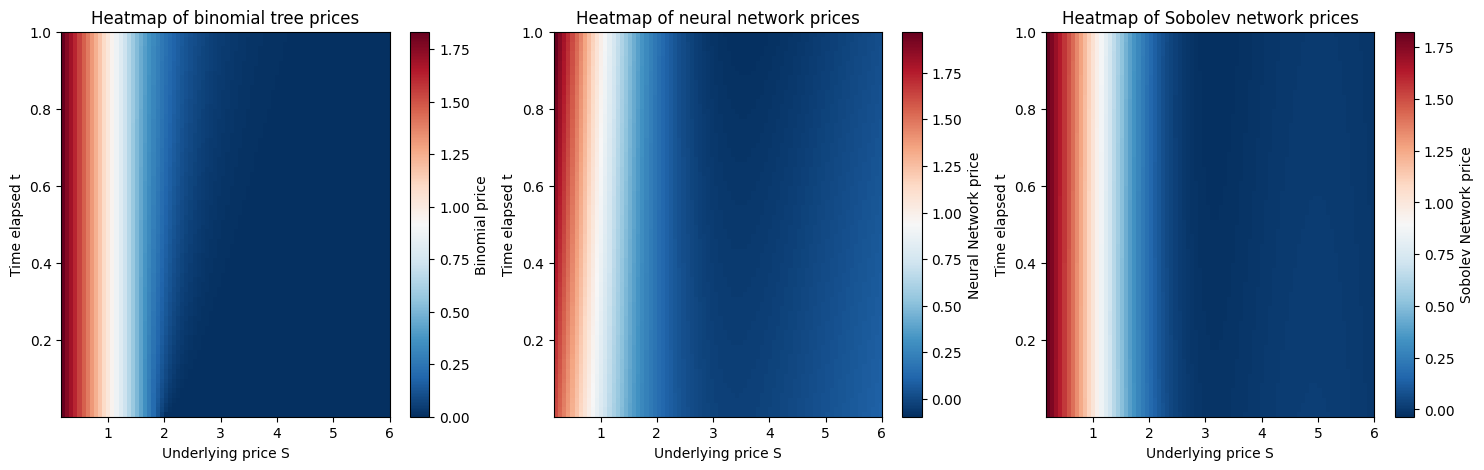

In [8]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
im = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of binomial tree prices')

plt.subplot(1, 3, 2)
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Neural Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of neural network prices')

plt.subplot(1, 3, 3)
im = plt.imshow(sb_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Sobolev Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of Sobolev network prices')

plt.show()

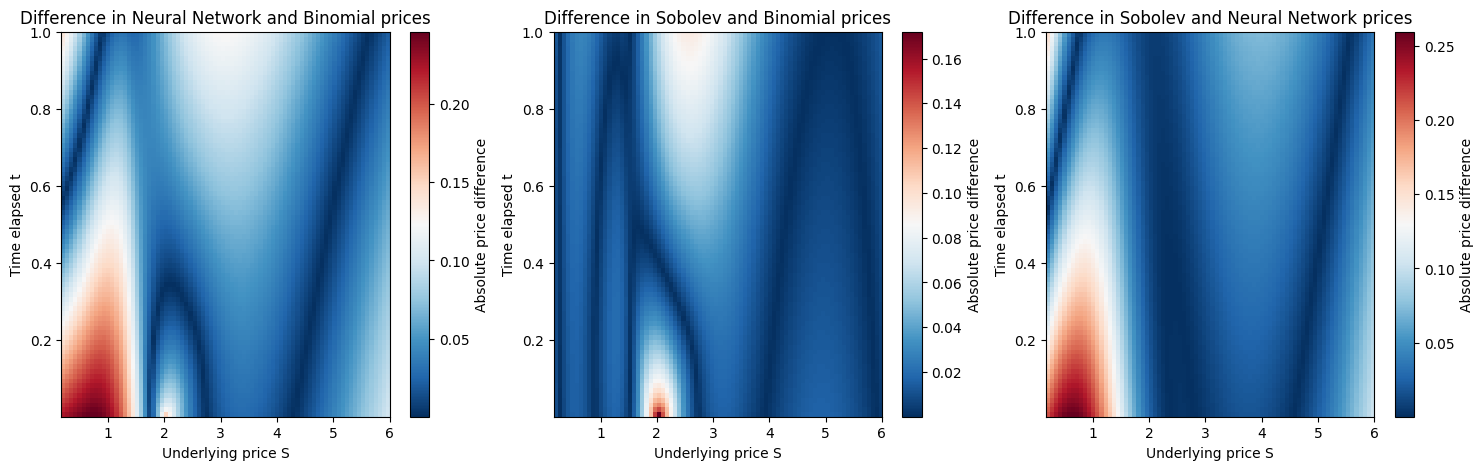

In [9]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

diff = abs(nn_prices - bt_prices)

im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Neural Network and Binomial prices')

plt.subplot(1, 3, 2)
diff = abs(sb_prices - bt_prices)

im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Sobolev and Binomial prices')

plt.subplot(1, 3, 3)

diff = abs(sb_prices - nn_prices)
im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Sobolev and Neural Network prices')

plt.show()